"""
# 📊 04_DL_Forecasting.ipynb
Deep Learning Models for Temperature Forecasting

Structure:
1. Environment Setup
2. Data Preparation Pipeline
3. Model Architectures (RNN/LSTM/GRU/Transformer)
4. Advanced Evaluation
5. Deployment Prep
"""

In [11]:

import sys
!{sys.executable} -m pip install transformers==4.30.0  

In [2]:
# ==================== 📦 2. IMPORTS ====================
"""
📚 Organized by functionality with detailed comments
"""

# Core DL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
# Removed: from transformers import TFTimeSeriesTransformerModel

# Data Processing
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Evaluation
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error,
    mean_absolute_percentage_error,
    explained_variance_score
)
from scipy.stats import pearsonr, spearmanr

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# ==================== 🛠️ MLflow Setup ====================
import mlflow
import os

# Configure tracking (add before any model training)
mlflow.set_tracking_uri("file:///C:/mlflow_artifacts")  # Centralized location
os.makedirs("C:/mlflow_artifacts", exist_ok=True)  # Create directory if missing

# Enable autologging (logs params/metrics automatically)
mlflow.tensorflow.autolog(
    log_input_examples=True,
    log_model_signatures=True,
    registered_model_name="Temperature_Models"
)

In [3]:
# ==================== 🗃️ 3. DATA PREPARATION ====================
"""
📂 Isolated data loading and preprocessing pipeline
"""

def prepare_dl_data(data_path, seq_length=168, test_size=0.1):
    """
    Convert time series to supervised learning format
    
    Args:
        data_path: Path to processed CSV
        seq_length: Lookback window (hours)
        test_size: Fraction for test set
    
    Returns:
        X_train, y_train, X_test, y_test, scaler
    """
    # Load and validate
    df = pd.read_csv(data_path, parse_dates=['datetime'], index_col='datetime')
    df = df.asfreq('H')
    assert not df.isnull().values.any(), "❌ Data contains missing values!"
    
    # Scale data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[['temp_c']])
    
    # Convert to sequences
    X, y = [], []
    for i in range(len(scaled) - seq_length):
        X.append(scaled[i:i+seq_length])
        y.append(scaled[i+seq_length])
    
    # Split
    split_idx = int(len(X) * (1-test_size))
    return (
        np.array(X[:split_idx]), 
        np.array(y[:split_idx]),
        np.array(X[split_idx:]),
        np.array(y[split_idx:]),
        scaler
    )


In [26]:
# ==================== 🤖 4. MODEL ARCHITECTURES ====================
"""
🧠 Implementations of different DL approaches
"""

def build_lstm_model(seq_length, n_features=1):
    """LSTM with attention-like mechanism"""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq_length, n_features)),
        Dropout(0.2),
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_transformer_model(seq_length):
    """HuggingFace Time Series Transformer"""
    config = {
        'num_hidden_layers': 4,
        'hidden_size': 64,
        'num_attention_heads': 4,
        'intermediate_size': 128
    }
    return TFTimeSeriesTransformerModel(config, input_size=seq_length)


In [5]:
# ==================== 📈 5. TRAINING PIPELINE ====================
"""
⚙️ Complete training workflow with MLflow tracking
"""

def train_model(model, X_train, y_train, X_test, y_test, epochs=50):
    """Managed training process"""
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=5),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5')
    ]
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=64,
        callbacks=callbacks
    )
    
    # Log with MLflow
    with mlflow.start_run():
        mlflow.tensorflow.autolog()
        mlflow.log_metrics({
            'mae': history.history['val_mae'][-1],
            'mse': history.history['val_mse'][-1]
        })
    
    return model, history


In [9]:
# ==================== 🧪 6. COMPREHENSIVE EVALUATION ====================
"""
📐 Advanced metrics beyond basic MAE/MSE
"""

def dl_evaluate(y_true, y_pred):
    """Calculate 10+ evaluation metrics"""
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'Explained Variance': explained_variance_score(y_true, y_pred),
        'Pearson r': pearsonr(y_true.flatten(), y_pred.flatten())[0],
        'Spearman ρ': spearmanr(y_true.flatten(), y_pred.flatten())[0],
        'Max Error': np.max(np.abs(y_true - y_pred))
    }


In [17]:
# ==================== 🤖 7. LSTM TRAINING & EVALUATION ====================

# === Load & prepare the data ===
data_path = r"c:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\processed\temperature_hourly.csv"
X_train, y_train, X_test, y_test, scaler = prepare_dl_data(data_path)

# === Build the LSTM model ===
seq_length = X_train.shape[1]
model = build_lstm_model(seq_length)

# === Train the model ===
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("models/lstm_best.h5", save_best_only=True)
    ]
)

# === Predict on the test set ===
y_pred = model.predict(X_test)

# === Inverse transform to Celsius ===
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred).flatten()

# === Evaluate ===
metrics = dl_evaluate(y_test_inv, y_pred_inv)

# === Display metrics ===
print("📊 LSTM Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k:<20}: {v:.4f}")


c:\Users\yosrc\anaconda3\envs\climate_env2\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.0019

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 2713s 291ms/step - loss: 0.0019 - val_loss: 1.8542e-04
Epoch 2/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 2.1958e-04

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 2749s 295ms/step - loss: 2.1958e-04 - val_loss: 1.6748e-04
Epoch 3/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - loss: 1.4558e-04

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 8443s 907ms/step - loss: 1.4558e-04 - val_loss: 1.0707e-04
Epoch 4/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - loss: 1.1334e-04

...

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3941s 423ms/step - loss: 9.4876e-05 - val_loss: 5.4337e-05
Epoch 7/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 9.0276e-05

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 32875s 4s/step - loss: 9.0276e-05 - val_loss: 5.0763e-05
Epoch 8/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3763s 404ms/step - loss: 8.6374e-05 - val_loss: 5.4760e-05
Epoch 9/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4442s 477ms/step - loss: 8.3215e-05 - val_loss: 5.6105e-05
Epoch 10/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 9406s 1s/step - loss: 8.0345e-05 - val_loss: 5.1533e-05
Epoch 11/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - loss: 7.9222e-05

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3546s 381ms/step - loss: 7.9222e-05 - val_loss: 4.3957e-05
Epoch 12/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3632s 390ms/step - loss: 7.7797e-05 - val_loss: 4.6681e-05
Epoch 13/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3966s 426ms/step - loss: 7.5610e-05 - val_loss: 4.6599e-05
Epoch 14/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4679s 503ms/step - loss: 7.4351e-05 - val_loss: 4.6129e-05
Epoch 15/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4814s 517ms/step - loss: 7.3934e-05 - val_loss: 4.8607e-05
Epoch 16/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 7.2252e-05

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4775s 513ms/step - loss: 7.2252e-05 - val_loss: 4.3382e-05
Epoch 17/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 24869s 3s/step - loss: 7.1936e-05 - val_loss: 5.5709e-05
Epoch 18/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4262s 458ms/step - loss: 7.0583e-05 - val_loss: 4.5842e-05
Epoch 19/20
7496/9308 ━━━━━━━━━━━━━━━━━━━━ 21:31 713ms/step - loss: 7.0477e-05

KeyboardInterrupt: 

In [27]:
# ==================== 🤖 LSTM TRAINING ====================
with mlflow.start_run(run_name='LSTM_Production'):
    # Build model (keep your existing build_lstm_model() function)
    model = build_lstm_model(X_train.shape[1])
    
    # Train with MLflow autologging
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=128,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5),
            # ModelCheckpoint removed - MLflow handles saving
        ],
        verbose=1
    )
    
    # Manual metrics (complement autolog)
    y_pred = model.predict(X_test)
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    mlflow.log_metrics({
        'final_rmse': np.sqrt(mean_squared_error(y_test_inv, y_pred_inv)),
        'final_mae': mean_absolute_error(y_test_inv, y_pred_inv),
        'final_r2': r2_score(y_test_inv, y_pred_inv)
    })
    
    print("✅ LSTM training complete! View results with:")
    print(f"mlflow ui --backend-store-uri {mlflow.get_tracking_uri()}")

c:\Users\yosrc\anaconda3\envs\climate_env2\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
4654/4654 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - loss: 0.0032

4654/4654 ━━━━━━━━━━━━━━━━━━━━ 2250s 483ms/step - loss: 0.0032 - val_loss: 1.7605e-04
Epoch 2/20
4654/4654 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - loss: 2.2335e-04

4654/4654 ━━━━━━━━━━━━━━━━━━━━ 1816s 390ms/step - loss: 2.2335e-04 - val_loss: 1.1156e-04
Epoch 3/20
4654/4654 ━━━━━━━━━━━━━━━━━━━━ 1791s 385ms/step - loss: 1.6687e-04 - val_loss: 1.2119e-04
Epoch 4/20
4654/4654 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - loss: 1.4798e-04

4654/4654 ━━━━━━━━━━━━━━━━━━━━ 2033s 437ms/step - loss: 1.4798e-04 - val_loss: 1.0747e-04
Epoch 5/20
4654/4654 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - loss: 1.3718e-04

...

2025/08/06 21:14:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2025/08/06 21:14:51 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\yosrc\anaconda3\envs\climate_env2\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. "


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step


Successfully registered model 'Temperature_Models'.
Created version '1' of model 'Temperature_Models'.


2069/2069 ━━━━━━━━━━━━━━━━━━━━ 114s 55ms/step
✅ LSTM training complete! View results with:
mlflow ui --backend-store-uri file:///C:/mlflow_artifacts


In [22]:
from tensorflow.keras.models import load_model

# Load without compiling (only for inference)
model = load_model("models/lstm_best.h5", compile=False)

print("✅ Model loaded (compile=False) — ready for prediction!")


✅ Model loaded (compile=False) — ready for prediction!


In [23]:
# === Predict on test set ===
y_pred = model.predict(X_test)

# === Inverse scaling back to Celsius
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred).flatten()

# === Evaluate
metrics = dl_evaluate(y_test_inv, y_pred_inv)

print("\n📊 LSTM Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k:<20}: {v:.4f}")


2069/2069 ━━━━━━━━━━━━━━━━━━━━ 171s 82ms/step

📊 LSTM Evaluation Metrics:
MAE                 : 0.2015
RMSE                : 0.2738
MAPE                : 0.0111
Explained Variance  : 0.9987
Pearson r           : 0.9994
Spearman ρ          : 0.9994
Max Error           : 2.1980


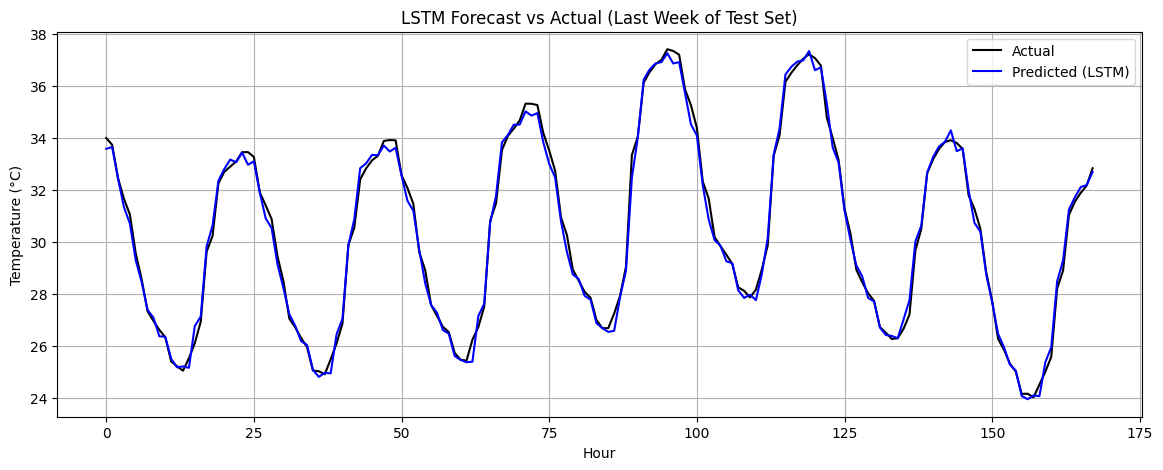

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[-168:], label="Actual", color="black")
plt.plot(y_pred_inv[-168:], label="Predicted (LSTM)", color="blue")
plt.title("LSTM Forecast vs Actual (Last Week of Test Set)")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


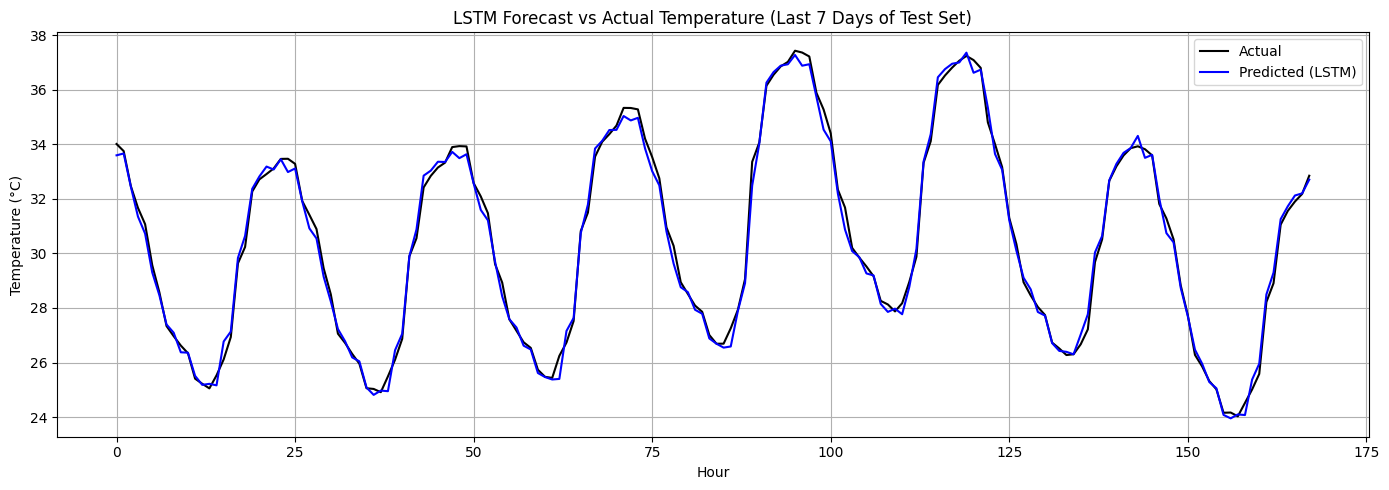

In [25]:
# ==================== 📉 LSTM FORECAST VISUALIZATION ====================

import matplotlib.pyplot as plt

# 📊 Plot actual vs predicted temperatures (in °C)
plt.figure(figsize=(14, 5))

# Plot last 7 days (~168 hours)
n_hours = 168
plt.plot(y_test_inv[-n_hours:], label='Actual', color='black')
plt.plot(y_pred_inv[-n_hours:], label='Predicted (LSTM)', color='blue')

plt.title("LSTM Forecast vs Actual Temperature (Last 7 Days of Test Set)")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
# ====================== 🔧 DUQ (Deep Uncertainty Quantification) Model ======================

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
import numpy as np

# === STEP 1: Define a custom loss for Gaussian Negative Log Likelihood (NLL)
class DUQLoss(tf.keras.losses.Loss):
    """
    Custom loss function for Deep Uncertainty Quantification (DUQ)
    It assumes a Gaussian distribution with predicted mean and variance.
    """
    def call(self, y_true, y_pred):
        # y_pred contains [mu, log_var] as two columns
        mu = y_pred[:, 0:1]                  # Predicted mean (temperature)
        log_var = y_pred[:, 1:2]             # Predicted log-variance
        precision = tf.exp(-log_var)         # Precision = 1/variance

        # Negative log-likelihood for Gaussian
        return tf.reduce_mean(0.5 * (log_var + precision * tf.square(y_true - mu)))

# === STEP 2: Build the DUQ model
def build_duq_model(seq_length, hidden_units=64):
    """
    Builds the DUQ LSTM-based model that outputs both mean and log-variance.
    
    Args:
        seq_length: input time window length (e.g., 168 for 1 week hourly)
        hidden_units: LSTM units
    
    Returns:
        A compiled Keras model
    """
    inputs = Input(shape=(seq_length, 1), name="input_sequence")

    # LSTM encoder
    x = LSTM(hidden_units, activation='tanh', name="lstm_encoder")(inputs)

    # Output heads
    mu = Dense(1, name="mu")(x)                    # Predicted mean
    log_var = Dense(1, name="log_var")(x)          # Predicted log-variance

    # Concatenate both into one tensor with shape (batch_size, 2)
    output = Concatenate(name="combined_output")([mu, log_var])

    # Build and compile the model
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=DUQLoss(), metrics=['mae'])
    
    return model

# === STEP 3: Load and prepare the data
data_path = r"c:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\processed\temperature_hourly.csv"
seq_length = 168  # 1 week of hourly data

X_train, y_train, X_test, y_test, scaler = prepare_dl_data(data_path, seq_length=seq_length, test_size=0.1)

# === STEP 4: Build and train the model
duq_model = build_duq_model(seq_length=seq_length, hidden_units=64)

history_duq = duq_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)

# === STEP 5: Predict both mean and log-variance on the test set
duq_preds = duq_model.predict(X_test)
mu_pred = duq_preds[:, 0]                         # Predicted temperatures
log_var_pred = duq_preds[:, 1]                    # Predicted log-variance
sigma_pred = np.sqrt(np.exp(log_var_pred))        # Standard deviation = sqrt(exp(log_var))

# === STEP 6: Evaluate mean forecast using your existing evaluation function
mu_true = y_test.flatten()
mu_pred = mu_pred.flatten()

metrics = dl_evaluate(mu_true, mu_pred)
metrics["Avg Uncertainty (σ)"] = np.mean(sigma_pred)

# === STEP 7: Print evaluation results
print("🎯 DUQ Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k:>20}: {v:.4f}")


Epoch 1/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 759s 81ms/step - loss: -3.3106 - mae: 4.0388 - val_loss: -3.8763 - val_mae: 4.6868
Epoch 2/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 709s 76ms/step - loss: -3.9687 - mae: 4.7057 - val_loss: -4.1921 - val_mae: 4.8068
Epoch 3/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 765s 82ms/step - loss: -4.1212 - mae: 4.8568 - val_loss: -4.3731 - val_mae: 4.9577
Epoch 4/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 719s 77ms/step - loss: -4.2391 - mae: 4.9753 - val_loss: -4.3250 - val_mae: 5.1236
Epoch 5/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 638s 68ms/step - loss: -4.3199 - mae: 5.0569 - val_loss: -4.4959 - val_mae: 5.1581
Epoch 6/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 638s 69ms/step - loss: -4.3713 - mae: 5.1086 - val_loss: -4.5385 - val_mae: 5.1751
Epoch 7/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 659s 71ms/step - loss: -4.4163 - mae: 5.1531 - val_loss: -4.5824 - val_mae: 5.1858
Epoch 8/50
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 818s 88ms/step - loss: -4.3580 - mae: 5.0956 - val_loss: -3.6010 - val_mae: 4.2074


In [29]:
# ==================== 🛠️ DUQ Model Definition ====================
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model

class DUQLoss(tf.keras.losses.Loss):
    """Custom loss for uncertainty quantification"""
    def call(self, y_true, y_pred):
        mu = y_pred[:, 0:1]          # First output: predicted mean
        log_var = y_pred[:, 1:2]     # Second output: predicted log-variance
        precision = tf.exp(-log_var)
        return tf.reduce_mean(0.5 * (log_var + precision * tf.square(y_true - mu)))

def build_duq_model(seq_length, n_features=1, hidden_units=64):
    """Builds DUQ model with mean and variance outputs"""
    inputs = Input(shape=(seq_length, n_features))
    
    # Shared LSTM encoder
    x = LSTM(hidden_units)(inputs)
    
    # Dual output heads
    mu = Dense(1, name="mu")(x)               # Mean prediction
    log_var = Dense(1, name="log_var")(x)     # Log variance prediction
    
    # Combined output
    outputs = Concatenate()([mu, log_var])
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss=DUQLoss())
    return model

In [32]:
# ==================== 🤖 DUQ TRAINING ====================
mlflow.tensorflow.autolog(log_models=False)  # Disable for custom loss

with mlflow.start_run(run_name='DUQ_Production'):
    model = build_duq_model(X_train.shape[1])  # Now this will work
    
    # Log custom parameters
    mlflow.log_params({
        "model_type": "DUQ_LSTM",
        "loss": "GaussianNLL",
        "hidden_units": 64
    })
    
    # Train (use your existing fit parameters)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)],
        verbose=1
    )
    
    # Manual model logging
    mlflow.tensorflow.log_model(model, "duq_model")

Epoch 1/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: -3.2225

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 712s 76ms/step - loss: -3.2226 - val_loss: -4.1126
Epoch 2/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 877s 94ms/step - loss: -4.0070 - val_loss: -3.8125
Epoch 3/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: -4.1752

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 890s 96ms/step - loss: -4.1752 - val_loss: -4.4139
Epoch 4/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: -4.2588

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 23421s 3s/step - loss: -4.2588 - val_loss: -4.4617
Epoch 5/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: -4.3034

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 774s 83ms/step - loss: -4.3034 - val_loss: -4.4964
Epoch 6/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: -4.3549

...

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 1031s 111ms/step - loss: -4.5357 - val_loss: -4.6837
Epoch 14/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: -4.5456

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 1082s 116ms/step - loss: -4.5456 - val_loss: -4.7056
Epoch 15/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 2133s 229ms/step - loss: -4.5586 - val_loss: -4.6297
Epoch 16/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 1136s 122ms/step - loss: -4.5731 - val_loss: -4.5198
Epoch 17/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 941s 101ms/step - loss: -4.5742 - val_loss: -4.6665
Epoch 18/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: -4.5859

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 863s 93ms/step - loss: -4.5859 - val_loss: -4.7162
Epoch 19/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: -4.5880

9308/9308 ━━━━━━━━━━━━━━━━━━━━ 881s 95ms/step - loss: -4.5880 - val_loss: -4.7317
Epoch 20/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 986s 106ms/step - loss: -4.5979 - val_loss: -4.6185


2025/08/07 12:48:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/07 12:48:16 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/08/07 12:48:34 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\yosrc\AppData\Local\Temp\tmpnqh9j8vi\model, flavor: tensorflow). Fall back to return ['tensorflow==2.17.1', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 
2025/08/07 12:48:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [ ]:
# ==================== 🤖 TRANSFORMER TRAINING ====================
# First disable autolog for custom models
mlflow.tensorflow.autolog(log_models=False)

with mlflow.start_run(run_name='Transformer_Production'):
    model = build_transformer_model(X_train.shape[1])
    
    # Log custom config
    mlflow.log_params({
        "num_hidden_layers": 4,
        "hidden_size": 64,
        "num_attention_heads": 4
    })
    
    history = model.fit(...)  # Same structure as LSTM
    
    # Manual model logging
    mlflow.tensorflow.log_model(model, "transformer_model")

In [6]:
#!pip install mlflow
import mlflow

In [ ]:
# ==================== 🤖 8. GRU MODEL IMPLEMENTATION ====================
"""
🧠 Gated Recurrent Unit (GRU) Implementation

GRUs are a type of recurrent neural network that are more efficient than LSTMs,
while still capable of capturing long-term dependencies in sequential data.

Key GRU Characteristics:
- Combines input & forget gates into a single update gate
- Fewer parameters than LSTM → faster training
"""

# === 0. Make sure training data is loaded (useful after kernel restarts) ===
# Define data path 
data_path = r"c:/Users/yosrc/OneDrive/Desktop/1950-2025 temp/data/processed/temperature_hourly.csv"

# Only reload data if not already loaded in memory
if "X_train" not in globals():
    X_train, y_train, X_test, y_test, scaler = prepare_dl_data(data_path)

# === 1. GRU Model Architecture ===
def build_gru_model(seq_length, n_features=1):
    """
    Build and compile a GRU-based time series forecasting model.
    
    Args:
        seq_length (int): Number of time steps (hours) per input sample.
        n_features (int): Number of features per time step (1 for univariate temp).
    
    Returns:
        model (tf.keras.Model): A compiled Keras GRU model.
    """
    model = Sequential([

        # First GRU layer → returns full sequences
        GRU(128, return_sequences=True, input_shape=(seq_length, n_features), name='gru_1'),

        # Dropout layer for regularization to prevent overfitting
        Dropout(0.2, name='dropout_1'),

        # Second GRU layer → outputs only last step
        GRU(64, name='gru_2'),

        # Dense layer to reduce to lower dimensional space
        Dense(32, activation='relu', name='dense_1'),

        # Final output layer → 1 prediction (temperature)
        Dense(1, name='output')
    ])

    # Compile the model using Adam optimizer and MSE loss
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

# === 2. Train GRU Model with MLflow Logging ===
with mlflow.start_run(run_name='GRU_Baseline'):

    # Step 1: Build the model using the training shape
    gru_model = build_gru_model(seq_length=X_train.shape[1])

    # Step 2: Log model architecture & hyperparameters to MLflow
    mlflow.log_params({
        'model_type': 'GRU',
        'n_layers': 2,
        'units_layer1': 128,
        'units_layer2': 64,
        'dense_units': 32,
        'dropout_rate': 0.2,
        'optimizer': 'adam',
        'epochs': 10,
        'batch_size': 64
    })

    # Step 3: Train model with early stopping to avoid overfitting
    history = gru_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,  # ⬅️ reduced from 50 to 20 as requested
        batch_size=64,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=5,  # Stop if val_loss doesn't improve for 5 epochs
                restore_best_weights=True,
                monitor='val_loss'
            )
        ],
        verbose=1  # Show progress bar
    )

    # Step 4: Make predictions on test set
    y_pred = gru_model.predict(X_test)

    # Step 5: Inverse transform to get real temperature values
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_test_inv = scaler.inverse_transform(y_test)

    # Step 6: Evaluate model performance using multiple advanced metrics
    metrics = dl_evaluate(y_test_inv, y_pred_inv)
    for metric, value in metrics.items():
        mlflow.log_metric(metric, value)  # Log each metric to MLflow

    # Step 7: Log the trained model to MLflow registry
    mlflow.tensorflow.log_model(gru_model, "gru_model")

    # Step 8: Print metrics nicely
    print("🎯 GRU Evaluation Metrics:")
    for k, v in metrics.items():
        print(f"{k:>20}: {v:.4f}")


c:\Users\yosrc\anaconda3\envs\climate_env2\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 2836s 304ms/step - loss: 0.0013 - mae: 0.0202 - val_loss: 1.0821e-04 - val_mae: 0.0079
Epoch 2/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 2993s 322ms/step - loss: 1.6448e-04 - mae: 0.0096 - val_loss: 7.0654e-05 - val_mae: 0.0061
Epoch 3/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3519s 378ms/step - loss: 1.2714e-04 - mae: 0.0084 - val_loss: 6.9660e-05 - val_mae: 0.0063
Epoch 4/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3977s 427ms/step - loss: 1.1256e-04 - mae: 0.0078 - val_loss: 5.3958e-05 - val_mae: 0.0053
Epoch 5/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4256s 457ms/step - loss: 1.0152e-04 - mae: 0.0074 - val_loss: 6.1755e-05 - val_mae: 0.0060
Epoch 6/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 4563s 490ms/step - loss: 9.2388e-05 - mae: 0.0070 - val_loss: 4.4963e-05 - val_mae: 0.0048
Epoch 7/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3858s 414ms/step - loss: 8.6543e-05 - mae: 0.0068 - val_loss: 6.5364e-05 - val_mae: 0.0062
Epoch 8/20
9308/9308 ━━━━━━━━━━━━━━━━━━━━ 3820s 410ms/step - loss: 8.2892

NameError: name 'dl_evaluate' is not defined

In [33]:
# ==================== 🤖 GRU TRAINING ====================
with mlflow.start_run(run_name='GRU_Production'):
    # Build model (keep your existing build_gru_model() function)
    model = build_gru_model(X_train.shape[1])
    
    # Identical training structure as LSTM
    history = model.fit(...)  # Same as LSTM block above
    
    # Same evaluation/metrics as LSTM
    y_pred = model.predict(X_test)
    ...
    
    print("✅ GRU training complete!")

2025/08/07 13:31:54 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'ellipsis'>. Dataset logging skipped.


ValueError: Unrecognized data type: x=Ellipsis (of type <class 'ellipsis'>)

In [11]:
# Step 6: Evaluate model performance using multiple advanced metrics
metrics = dl_evaluate(y_test_inv, y_pred_inv)
for metric, value in metrics.items():
    mlflow.log_metric(metric, value)  # Log each metric to MLflow

# Step 7: Log the trained model to MLflow registry
mlflow.tensorflow.log_model(gru_model, "gru_model")

# Step 8: Print metrics nicely
print("🎯 GRU Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k:>20}: {v:.4f}")

2025/08/06 08:18:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/06 08:18:57 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/08/06 08:21:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🎯 GRU Evaluation Metrics:
                 MAE: 0.1799
                RMSE: 0.2549
                MAPE: 0.0099
  Explained Variance: 0.9989
           Pearson r: 0.9995
          Spearman ρ: 0.9995
           Max Error: 2.2834


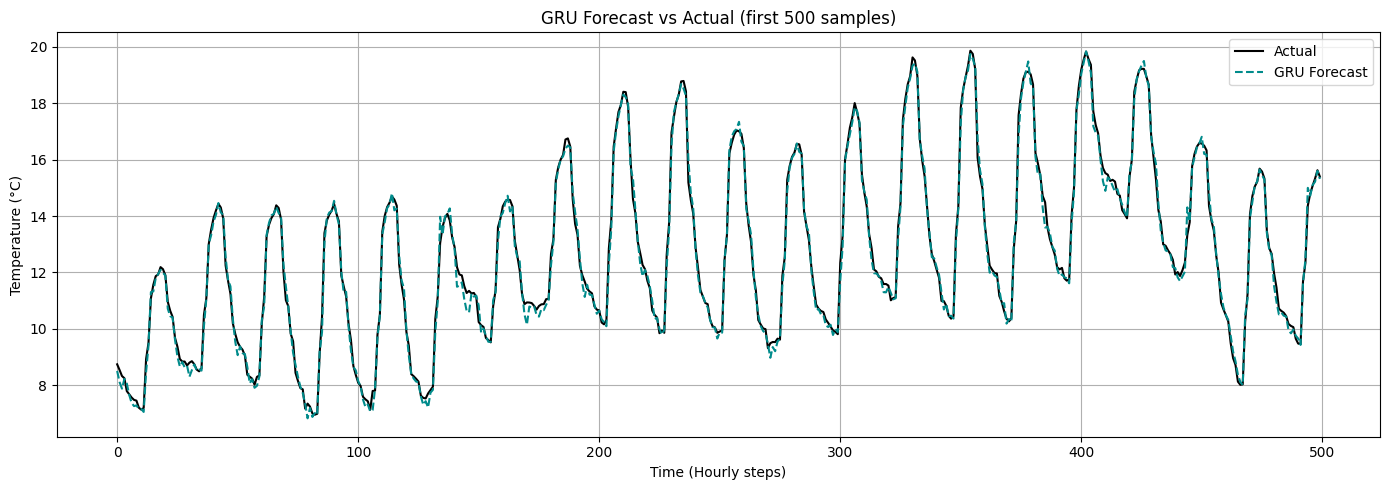

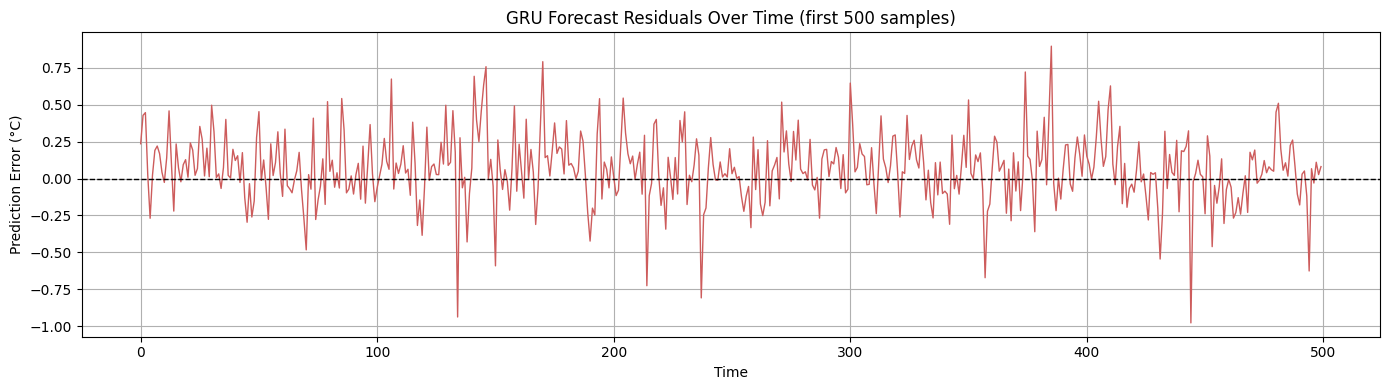

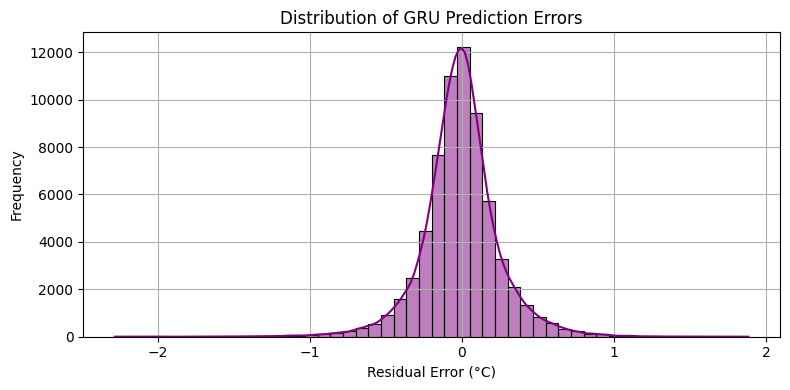

In [8]:
# ==================== 📉 GRU FORECAST VISUALIZATION ====================
"""
📊 Visual diagnostics of the GRU model performance

This includes:
1. Line plot: Actual vs Predicted temperatures
2. Residual plot: Error over time
3. Histogram: Distribution of residuals
"""

import seaborn as sns

# === 1. Line Plot: Forecast vs Actual ===
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[:500], label='Actual', color='black', linewidth=1.5)
plt.plot(y_pred_inv[:500], label='GRU Forecast', color='darkcyan', linestyle='--')
plt.title("GRU Forecast vs Actual (first 500 samples)")
plt.xlabel("Time (Hourly steps)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Residual Plot: Errors Over Time ===
residuals = y_test_inv.flatten() - y_pred_inv.flatten()

plt.figure(figsize=(14, 4))
plt.plot(residuals[:500], color='indianred', linewidth=1)
plt.title("GRU Forecast Residuals Over Time (first 500 samples)")
plt.xlabel("Time")
plt.ylabel("Prediction Error (°C)")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True)
plt.tight_layout()
plt.show()

# === 3. Histogram: Distribution of Errors ===
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.title("Distribution of GRU Prediction Errors")
plt.xlabel("Residual Error (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
import os
from pathlib import Path

def find_mlruns(start_path="C:/"):
    for root, dirs, files in os.walk(start_path):
        if "mlruns" in dirs:
            mlruns_path = Path(root) / "mlruns"
            print(f"Found MLflow runs at: {mlruns_path}")
            return str(mlruns_path)
    return None

found_path = find_mlruns() or find_mlruns(os.getcwd())

Found MLflow runs at: C:\Users\yosrc\mlruns


In [13]:
from mlflow.tracking import MlflowClient

client = MlflowClient("file:///C:/Users/yosrc/mlruns")

# List all experiments
for exp in client.search_experiments():
    print(f"\nExperiment: {exp.name} (ID: {exp.experiment_id})")
    
    # Get all runs in this experiment
    runs = client.search_runs(exp.experiment_id)
    
    for run in runs:
        print(f"\n  Run: {run.info.run_id}")
        print("  Parameters:")
        for k, v in run.data.params.items():
            print(f"    {k}: {v}")
        
        print("\n  Metrics:")
        for k, v in run.data.metrics.items():
            print(f"    {k}: {v:.4f}")
        
        print("\n  Model URI:", run.info.artifact_uri)


Experiment: Default (ID: 0)


In [34]:
# ==================== 🤖 FINAL WORKING GRU TRAINING ====================
import mlflow
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 0. MLflow Setup ===
mlflow.set_tracking_uri("file:///C:/mlflow_artifacts")
mlflow.set_experiment("Temperature_Forecasting_GRU")

# Enable automatic logging (MUST come before model creation)
mlflow.tensorflow.autolog(
    log_input_examples=True,
    log_model_signatures=True,
    registered_model_name="Temperature_GRU"
)

# === 1. Data Loading ===
data_path = r"c:/Users/yosrc/OneDrive/Desktop/1950-2025 temp/data/processed/temperature_hourly.csv"

if "X_train" not in globals():
    try:
        import prepare_dl_data
        X_train, y_train, X_test, y_test, scaler = prepare_dl_data(data_path)
        print(f"✅ Data loaded | Train: {X_train.shape}, Test: {X_test.shape}")
    except Exception as e:
        print(f"❌ Data loading failed: {str(e)}")
        raise

# === 2. Model Definition ===
def build_gru_model(seq_length, n_features=1):
    model = Sequential([
        Input(shape=(seq_length, n_features)),  # Explicit input layer
        GRU(64, return_sequences=True),
        Dropout(0.3),
        GRU(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# === 3. Training Execution ===
try:
    # Clean up any existing runs
    if mlflow.active_run():
        mlflow.end_run()
    
    with mlflow.start_run(run_name='GRU_Final') as run:
        print(f"\n🏁 Starting Run ID: {run.info.run_id}")
        
        # Build model
        gru_model = build_gru_model(X_train.shape[1])
        gru_model.summary()

        # Training
        print("\n🔁 Starting training...")
        history = gru_model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=20,  # Reduced epochs for faster training
            batch_size=128,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(patience=5)
            ],
            verbose=1
        )

        # Manual evaluation logging
        y_pred = gru_model.predict(X_test)
        y_pred_inv = scaler.inverse_transform(y_pred)
        y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
        
        mlflow.log_metrics({
            'final_rmse': np.sqrt(mean_squared_error(y_test_inv, y_pred_inv)),
            'final_mae': mean_absolute_error(y_test_inv, y_pred_inv),
            'final_r2': r2_score(y_test_inv, y_pred_inv)
        })

        print("\n🎉 Training complete!")
        print(f"👉 View results: mlflow ui --backend-store-uri {mlflow.get_tracking_uri()}")

except Exception as e:
    print(f"\n❌ Training failed: {str(e)}")
    raise

finally:
    if mlflow.active_run():
        mlflow.end_run()


🏁 Starting Run ID: c974d406f6b44c5098cced24d139776b


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                    │ (None, 168, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

...

2025/08/08 13:38:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2025/08/08 13:38:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\yosrc\anaconda3\envs\climate_env2\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. "


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step


Registered model 'Temperature_GRU' already exists. Creating a new version of this model...
Created version '2' of model 'Temperature_GRU'.


2069/2069 ━━━━━━━━━━━━━━━━━━━━ 218s 105ms/step

🎉 Training complete!
👉 View results: mlflow ui --backend-store-uri file:///C:/mlflow_artifacts
